In [46]:
import numpy as mp
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [47]:
df = pd.read_csv("HousingData.csv")

df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,NaN,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,NaN,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [48]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [49]:
for column in df.columns:
    df[column].fillna(df[column].mean(), inplace=True)

df.isnull().sum()

C:\Users\SHAHAJI KARANDE\AppData\Local\Temp\ipykernel_21820\964797004.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [50]:
#Features
X = df.drop('MEDV', axis=1)

#Target Variable
y = df['MEDV']

In [51]:
#Split dataset into training & testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [52]:
#Build Neural Network Model

model = Sequential()

model.add(Dense(128, input_shape=(13,), activation='relu', name='dense_1'))

model.add(Dense(64, activation='relu', name='dense_2'))

model.add(Dense(1, activation='linear', name='dense_output'))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

C:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 571.0867 - mae: 21.8055 - val_loss: 448.1322 - val_mae: 19.3694
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 428.9848 - mae: 18.3182 - val_loss: 287.8186 - val_mae: 14.9688
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 236.8316 - mae: 12.9928 - val_loss: 112.7663 - val_mae: 8.6430
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92.4215 - mae: 7.6472 - val_loss: 41.5732 - val_mae: 4.7179
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 46.2778 - mae: 5.3088 - val_loss: 28.6940 - val_mae: 3.7577
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29.3202 - mae: 4.0967 - val_loss: 25.9677 - val_mae: 3.6449
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24.1914 - mae: 3.6153 - val_loss: 25.7677 - val_mae: 3.6776
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21.8014 - mae: 3.3961 - val_loss: 24.6188 - val_mae: 3.5703
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━

In [54]:
#Predict on test data
y_pred = model.predict(X_test_scaled)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[32.8956   ],
       [42.201405 ],
       [18.561949 ],
       [26.582033 ],
       [14.765059 ],
       [22.551188 ],
       [19.591784 ],
       [16.500353 ],
       [23.697336 ],
       [19.774107 ],
       [23.691372 ],
       [21.875254 ],
       [ 3.4062471],
       [20.400187 ],
       [19.893713 ],
       [20.404219 ],
       [22.505022 ],
       [ 8.4762745],
       [56.41509  ],
       [11.073951 ],
       [28.904016 ],
       [31.181664 ],
       [15.038391 ],
       [24.841433 ],
       [14.128225 ],
       [15.477254 ],
       [20.60784  ],
       [13.011724 ],
       [22.091463 ],
       [19.256178 ],
       [26.079443 ],
       [25.476152 ],
       [15.733659 ],
       [21.208435 ],
       [13.701048 ],
       [18.404528 ],
       [36.891262 ],
       [22.377836 ],
       [24.267853 ],
       [26.30286  ],
       [17.852518 ],
       [34.651756 ],
       [60.44639  ],
       [19.978893 ],
       [30.644022 ],
       [12.308971 ],
       [15.849146 ],
       [28.30

In [57]:
#Compare Actual vs Predicted

for i in range(10):
    print("Actual Price: ", y_test.iloc[i],
          "Predicted Price: ", y_pred[i][0])

Actual Price:  23.6 Predicted Price:  32.8956
Actual Price:  32.4 Predicted Price:  42.201405
Actual Price:  13.6 Predicted Price:  18.561949
Actual Price:  22.8 Predicted Price:  26.582033
Actual Price:  16.1 Predicted Price:  14.765059
Actual Price:  20.0 Predicted Price:  22.551188
Actual Price:  17.8 Predicted Price:  19.591784
Actual Price:  14.0 Predicted Price:  16.500353
Actual Price:  19.6 Predicted Price:  23.697336
Actual Price:  16.8 Predicted Price:  19.774107


In [58]:
#Calculate Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mse

23.31251511465643

In [61]:
# Evaluate Model
metrics = model.evaluate(X_test_scaled, y_test)
metrics  #loss, mae, mse

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 23.3125 - mae: 3.5907


[23.312515258789062, 3.59073543548584]

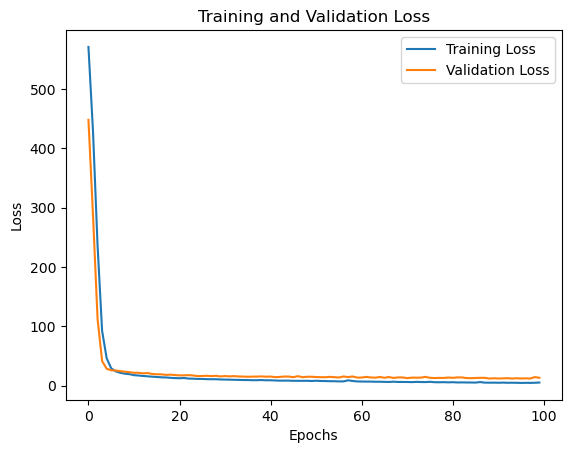

In [63]:
#Plot Training Loss

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.show()